In [97]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('default')

In [98]:
import numpy as np

class NoisySineModulator:
    def __init__(self, period=25000, noise_std=0.05, min_val=0.75, max_val=1.25, phase=0.0, seed=97):
        """
        A noisy sine wave modulator for smooth, periodic scaling values.

        Args:
            period (int): Number of steps per full sine cycle.
            noise_std (float): Standard deviation of Gaussian noise added to sine.
            min_val (float): Minimum value of the scaled output.
            max_val (float): Maximum value of the scaled output.
            phase (float): Phase offset for sine wave (in radians), useful for offsetting mass vs friction.
        """
        self.period = period
        self.noise_std = noise_std
        self.min_val = min_val
        self.max_val = max_val
        self.phase = phase
        self.rng = np.random.default_rng(seed)

    def sample(self, step: int):
        """Return modulated value at a given training step."""
        sine_val = 0.5 * (np.sin(2 * np.pi * step / self.period + self.phase) + 1)
        noisy_val = sine_val + self.rng.normal(0.0, self.noise_std)
        noisy_val = np.clip(noisy_val, 0.0, 1.0)
        scaled_val = self.min_val + (self.max_val - self.min_val) * noisy_val
        return scaled_val


In [99]:
# Create modulators with different seeds
slippery_mod = NoisySineModulator(period=2_000_000, phase=-np.pi / 2, seed=1, min_val=0, max_val=0.45)

In [100]:
# Sample every 10,000 steps
steps = np.arange(0, 10_000_001, 10_000)
slippery_vals = [slippery_mod.sample(step) for step in steps]

In [101]:
print(max(steps))

10000000


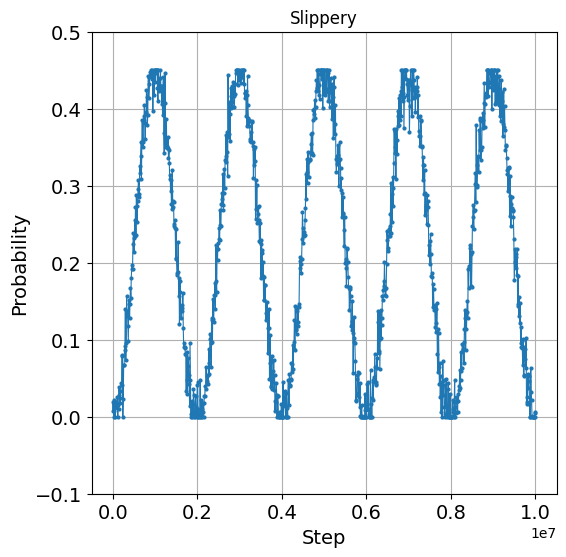

In [102]:
# Plot
plt.figure(figsize=(6, 6))
plt.plot(steps, slippery_vals, linewidth=0.8, marker='o', markersize=2)
plt.xlabel("Step", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("Slippery")
plt.grid(True)
plt.legend([], [], frameon=False)
plt.ylim(-0.1, 0.50)
# # Save the plot to a file
plt.savefig("slippery_sine_wave_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [103]:
class NoisyAPeriodicSineModulator:
    def __init__(
        self,
        period=25000,
        noise_std=0.05,
        min_val=0.75,
        max_val=1.25,
        phase=0.0,
        half_period_jitter=0.3,
        seed=97,
        num_train_steps=2_000_000,
        loop_step=10_000
    ):
        """
        A noisy, aperiodic sine modulator where frequency changes
        every half-cycle.

        Args:
            period (int): Average number of steps per full cycle.
            noise_std (float): Std of additive Gaussian noise.
            min_val, max_val (float): Output range.
            phase (float): Initial phase offset (radians).
            half_period_jitter (float): Relative jitter for half-cycle duration.
        """
        self.noise_std = noise_std
        self.min_val = min_val
        self.max_val = max_val
        self.phase = phase

        self.avg_half_period = period / 2
        self.half_period_jitter = half_period_jitter

        self.rng = np.random.default_rng(seed)
        self.start_index = 0
        self.end_index = num_train_steps
        self.loop_step = loop_step

        # phase bookkeeping
        self.phi = phase
        self._resample_half_cycle()


    def _resample_half_cycle(self):
        """Sample duration and frequency for the next half-cycle."""
        jitter = 1.0 + self.half_period_jitter * self.rng.standard_normal()
        self.half_period = max(1.0, self.avg_half_period * jitter)

        # angular frequency so that π phase advance == half-cycle
        self.omega = np.pi / self.half_period
        self.phase_remaining = np.pi

    def sample(self):
        """Return modulated value at the current step."""
        dphi = self.omega

        if dphi >= self.phase_remaining:
            # hit half-cycle boundary
            self.phi += self.phase_remaining
            leftover = dphi - self.phase_remaining

            # resample frequency for next half-cycle
            self._resample_half_cycle()

            # consume leftover phase
            self.phi += leftover
            self.phase_remaining -= leftover
        else:
            self.phi += dphi
            self.phase_remaining -= dphi

        # sine in [0,1]
        sine_val = 0.5 * (np.sin(self.phi) + 1.0)

        # add noise
        noisy_val = sine_val + self.rng.normal(0.0, self.noise_std)
        # noisy_val = np.clip(noisy_val, 0.0, 1.0)
        current_val = self.min_val + (self.max_val - self.min_val) * noisy_val

        return current_val

In [104]:
nonperiodic_slippery_mod = NoisyAPeriodicSineModulator(
    # period=250_000,
    period=500_000,
    phase=0,
    seed=1,
    min_val=0.0,
    max_val=0.45,
    half_period_jitter=0.8,
    noise_std=0.05,
)

# slippery_mod = NoisySineModulator(period=2_000_000, phase=-np.pi / 2, seed=1, min_val=0, max_val=0.45)

In [105]:
# Sample every 10,000 steps
# steps = np.arange(0, 2_000_001, 10_000)
# vals = [nonperiodic_mass_mod.sample() for step in steps]

vals = []
for i in range(10_000_001):
    v = nonperiodic_slippery_mod.sample()
    if i % 10_000 == 0:
        vals.append(v)

In [106]:
# print(vals)
print(len(steps))
print(len(vals))


1001
1001


In [107]:
print(len(slippery_vals))
print(max(steps))

1001
10000000


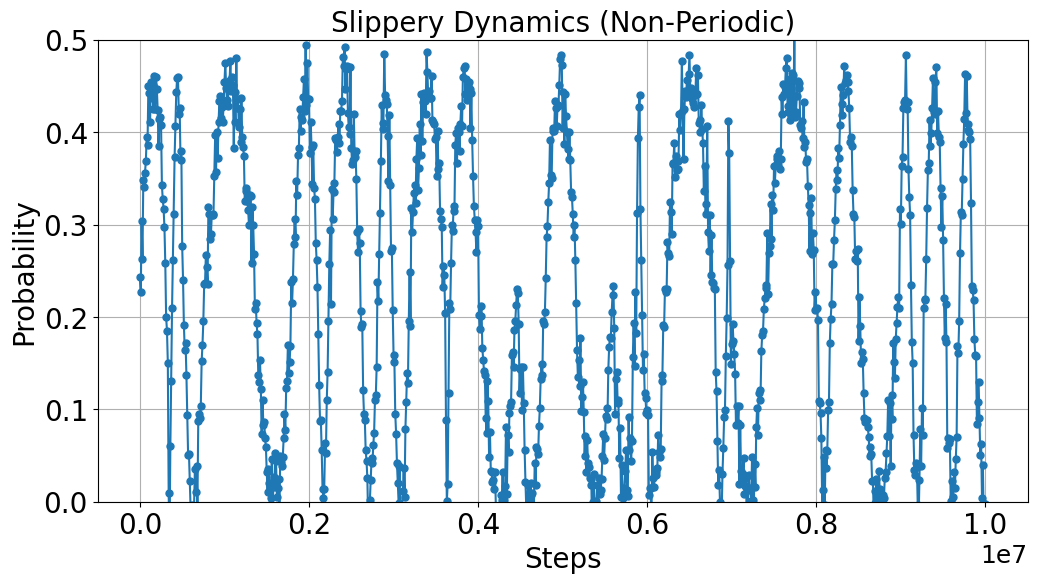

In [108]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(steps, vals, label="Non-Periodic Slippery Scale", marker='o', markersize=5)
plt.xlabel("Steps", fontsize=20)
plt.ylabel("Probability", fontsize=20)
plt.tick_params(axis="x", labelsize=20)
plt.tick_params(axis="y", labelsize=20)
plt.title("Slippery Dynamics (Non-Periodic)", fontsize=20)
plt.grid(True)
plt.legend([], [], frameon=False)
plt.ylim(0.0, 0.50)
plt.gca().xaxis.get_offset_text().set_fontsize(18)
# plt.legend(loc="lower right")
# plt.ylim(0.4, 2.2)
# plt.ylim(-1.1, 1.1)
# # Save the plot to a file
# plt.savefig("sine_wave_plot_mass.pdf", dpi=300, bbox_inches="tight")
plt.savefig("nonperiodic_sine_wave_plot_slippery.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("sine_wave_plot_foward_backward.pdf", dpi=300, bbox_inches="tight")
plt.show()

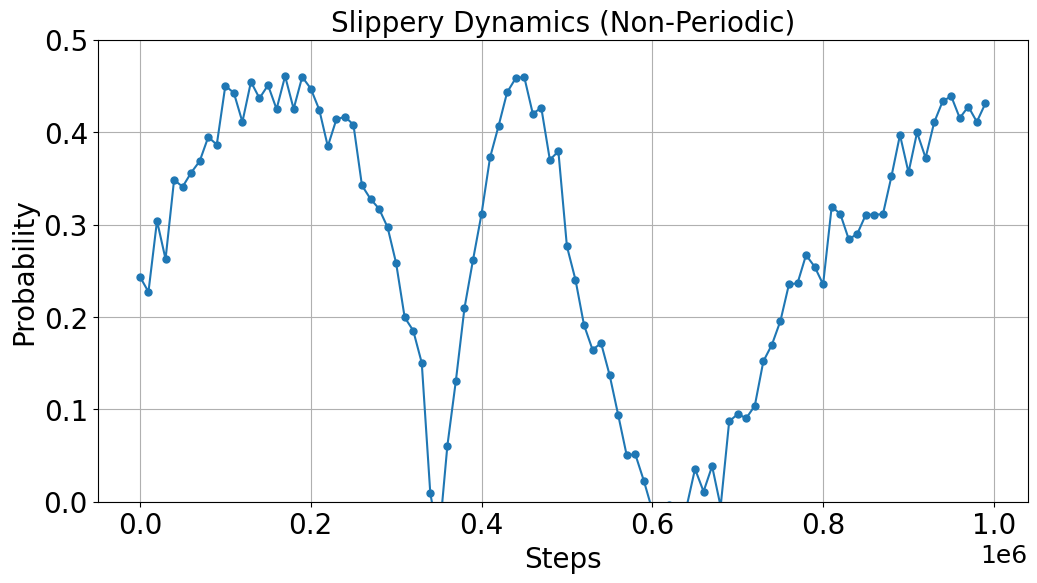

In [109]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(steps[:100], vals[:100], label="Non-Periodic Slippery Scale", marker='o', markersize=5)
plt.xlabel("Steps", fontsize=20)
plt.ylabel("Probability", fontsize=20)
plt.tick_params(axis="x", labelsize=20)
plt.tick_params(axis="y", labelsize=20)
plt.title("Slippery Dynamics (Non-Periodic)", fontsize=20)
plt.grid(True)
plt.legend([], [], frameon=False)
plt.ylim(0.0, 0.50)
plt.gca().xaxis.get_offset_text().set_fontsize(18)
# plt.legend(loc="lower right")
# plt.ylim(0.4, 2.2)
# plt.ylim(-1.1, 1.1)
# # Save the plot to a file
# plt.savefig("sine_wave_plot_mass.pdf", dpi=300, bbox_inches="tight")
plt.savefig("nonperiodic_sine_wave_plot_slippery_subset.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("sine_wave_plot_foward_backward.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [110]:

class OUDrift:
    def __init__(self, mu=0.5, theta=0.01, sigma=0.02, low=0.9, high=1.1, x0=None, seed=97):
        """
        Ornstein–Uhlenbeck drift generator.

        Parameters:
            mu : float      - long-term mean
            theta : float   - mean reversion rate (smaller = slower drift)
            sigma : float   - noise magnitude
            x0 : float      - initial value (optional)
        """
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.low = low
        self.high = high
        self.x_prev = np.clip(x0 if x0 is not None else mu, self.low, self.high)
        self.rng = np.random.default_rng(seed)


    def sample(self):
        """
        Returns the next value in the OU drift process.
        """
        # epsilon = np.random.randn()
        epsilon = self.rng.standard_normal()
        x = self.x_prev + self.theta * (self.mu - self.x_prev) + self.sigma * epsilon
        x = np.clip(x, self.low, self.high)
        self.x_prev = x
        return x

    def reflect(self, x):
        if x < self.low:
            x = self.low + (self.low - x)
        elif x > self.high:
            x = self.high - (x - self.high)
        return x

In [111]:
#Walker
ou_mod = OUDrift(mu=0.15, theta=0.001, sigma=0.1, low=0, high=0.45, seed=97)

In [112]:
# Sample every 10,000 steps
# steps = np.arange(0, 1_000_001, 10_000)
# vals = [nonperiodic_mass_mod.sample() for step in steps]

vals = []
for i in range(10_000_001):
    v = ou_mod.sample()
    if i % 10_000 == 0:
        vals.append(v)

# print(vals)
print(len(steps))
print(len(vals))

1001
1001


In [113]:
print(max(steps))

10000000


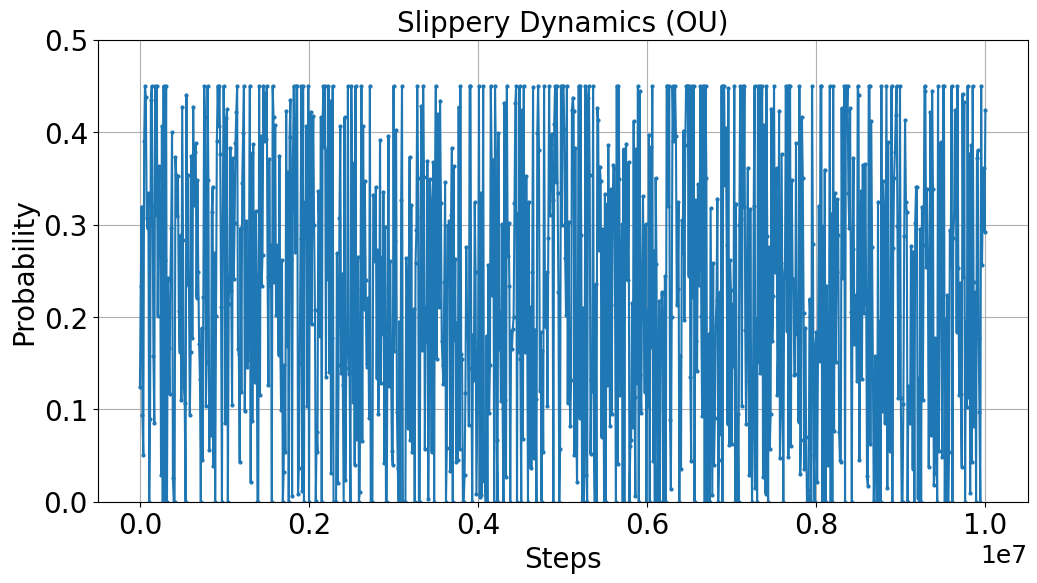

In [114]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(steps, vals, label="OU Slippery Scale", marker='o', markersize=2)
plt.xlabel("Steps", fontsize=20)
plt.ylabel("Probability", fontsize=20)
plt.tick_params(axis="x", labelsize=20)
plt.tick_params(axis="y", labelsize=20)
plt.title("Slippery Dynamics (OU)", fontsize=20)
plt.grid(True)
plt.legend([], [], frameon=False)
plt.ylim(0.0, 0.50)
plt.gca().xaxis.get_offset_text().set_fontsize(18)
# plt.legend(loc="lower right")
# plt.ylim(0.4, 2.2)
# plt.ylim(-1.1, 1.1)
# # Save the plot to a file
# plt.savefig("sine_wave_plot_mass.pdf", dpi=300, bbox_inches="tight")
plt.savefig("OU_plot_slippery.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("sine_wave_plot_foward_backward.pdf", dpi=300, bbox_inches="tight")
plt.show()

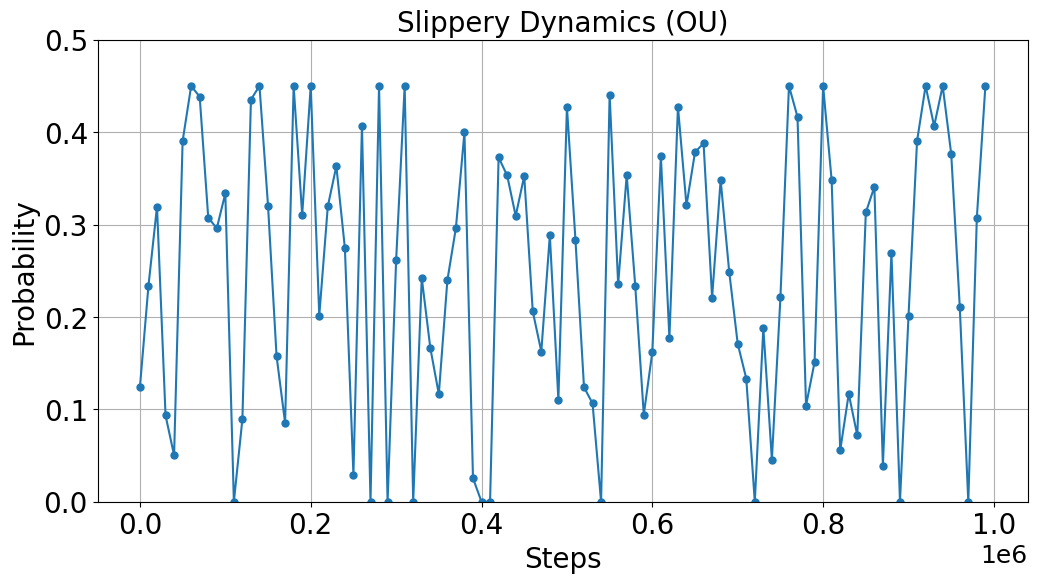

In [115]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(steps[:100], vals[:100], label="OU Slippery Scale", marker='o', markersize=5)
plt.xlabel("Steps", fontsize=20)
plt.ylabel("Probability", fontsize=20)
plt.tick_params(axis="x", labelsize=20)
plt.tick_params(axis="y", labelsize=20)
plt.title("Slippery Dynamics (OU)", fontsize=20)
plt.grid(True)
plt.legend([], [], frameon=False)
plt.ylim(0.0, 0.50)
plt.gca().xaxis.get_offset_text().set_fontsize(18)
# plt.legend(loc="lower right")
# plt.ylim(0.4, 2.2)
# plt.ylim(-1.1, 1.1)
# # Save the plot to a file
# plt.savefig("sine_wave_plot_mass.pdf", dpi=300, bbox_inches="tight")
plt.savefig("OU_plot_slippery_subset.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("sine_wave_plot_foward_backward.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [116]:
# ou_mod_2 = OUDrift(mu=0.15, theta=0.001, sigma=0.1, low=0, high=0.45, seed=97)
#
# # Sample every 10,000 steps
# steps = np.arange(0, 1_000_001, 10_000)
# # vals = [nonperiodic_mass_mod.sample() for step in steps]
#
# vals_b = []
# for _ in range(1_000_001):
#     v = ou_mod_2.sample()
#     if _ % 10_000 == 0:
#         vals_b.append(v)
#
# # print(vals)
# print(len(steps))
# print(len(vals_b))

In [117]:
# # Plot
# plt.figure(figsize=(12, 6))
# plt.plot(steps, vals_b, label="OU Slippery Scale", marker='o', markersize=5)
# plt.xlabel("Steps", fontsize=14)
# plt.ylabel("Probability", fontsize=14)
# plt.tick_params(axis="x", labelsize=14)
# plt.tick_params(axis="y", labelsize=14)
# plt.title("Slippery Dynamics (OU)", fontsize=20)
# plt.grid(True)
# plt.legend([], [], frameon=False)
# plt.ylim(-0.1, 0.50)
# # plt.gca().xaxis.get_offset_text().set_fontsize(20)
# # plt.legend(loc="lower right")
# # plt.ylim(0.4, 2.2)
# # plt.ylim(-1.1, 1.1)
# # # Save the plot to a file
# # plt.savefig("sine_wave_plot_mass.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("OU_plot_slippery.pdf", dpi=300, bbox_inches="tight")
# # plt.savefig("sine_wave_plot_foward_backward.pdf", dpi=300, bbox_inches="tight")
# plt.show()
#
#
# # Plot
# # plt.figure(figsize=(6, 6))
# # plt.plot(steps, slippery_vals, linewidth=0.8, marker='o', markersize=2)
# # plt.xlabel("Step", fontsize=14)
# # plt.ylabel("Probability", fontsize=14)
# # plt.xticks(fontsize=14)
# # plt.yticks(fontsize=14)
# # plt.title("Slippery")
# # plt.grid(True)
# # plt.legend([], [], frameon=False)
# # plt.ylim(-0.1, 0.50)
# # # # Save the plot to a file
# # plt.savefig("slippery_sine_wave_plot.pdf", dpi=300, bbox_inches="tight")
# # plt.show()